# Bangkok Traffic V4 — เลือก Raw Data ใหม่และรันทุกเซลล์

โค้ดรวมอยู่ในไฟล์นี้แล้ว ไม่ต้องอัปโหลด src; ผลแต่ละรอบอยู่คนละโฟลเดอร์ กราฟและคำอธิบายคำนวณใหม่ ใช้ชีต traffic_data และ covid_period ตามไฟล์

V4 แสดง Before/During/After ชัดเจน เพิ่ม Lockdown ภายใน During ตาม flag ในไฟล์ ไม่แก้สถานะอัตโนมัติ และรายงานความไวต่อนิยามวันที่

In [1]:
from pathlib import Path
import os,sys,subprocess,importlib.util
for mod in ['pandas','numpy','matplotlib','openpyxl']:
    if importlib.util.find_spec(mod) is None: subprocess.check_call([sys.executable,'-m','pip','install',mod])
from IPython.display import display,Image,Markdown
IN_COLAB='google.colab' in sys.modules
WORK=Path.cwd()/'traffic_v4_runtime'
(WORK/'src').mkdir(parents=True,exist_ok=True)

## เลือกไฟล์
บน Colab อัปโหลด Excel หนึ่งไฟล์ ส่วนเครื่อง local ให้กรอก INPUT_PATH ไม่ต้องแก้ส่วนวิเคราะห์

In [2]:
INPUT_PATH = ''
chosen=INPUT_PATH or os.environ.get('TRAFFIC_INPUT','')
if not chosen and IN_COLAB:
    from google.colab import files
    uploaded=files.upload()
    names=[n for n in uploaded if n.lower().endswith('.xlsx')]
    if len(names)!=1: raise ValueError('Upload exactly one .xlsx workbook')
    chosen=names[0]
if not chosen: raise ValueError('Set INPUT_PATH to your workbook')
SOURCE=Path(chosen).resolve()
assert SOURCE.is_file()

## โค้ดที่ใช้คำนวณ
โค้ดใน cell นี้สร้างโมดูลภายใน runtime ของ Notebook เท่านั้น ไม่แก้โปรเจคเดิม

In [3]:
sources = {'audit_core.py': '"""Reproducible feasibility audit. No traffic-volume EDA or charts."""\nfrom pathlib import Path\nimport argparse, datetime, hashlib, json, re, shutil, unicodedata\nimport numpy as np\nimport pandas as pd\n\nROOT = Path(__file__).resolve().parents[1]\nVEHICLES = [\'passenger_car\',\'pickup_van\',\'large_bus\',\'small_bus\',\'truck\',\'tuk_tuk\']\nPERIODS = [\'ก่อนโควิด\',\'โควิด\',\'หลังโควิด\']\nTHAI_MONTHS = [\'ม.ค.\',\'ก.พ.\',\'มี.ค.\',\'เม.ย.\',\'พ.ค.\',\'มิ.ย.\',\'ก.ค.\',\'ส.ค.\',\'ก.ย.\',\'ต.ค.\',\'พ.ย.\',\'ธ.ค.\']\n\ndef normalize(value):\n    if pd.isna(value): return \'\'\n    return re.sub(r\'\\s+\', \' \', unicodedata.normalize(\'NFC\',str(value))).strip()\n\ndef survey_date(value):\n    if pd.isna(value): return pd.NaT\n    if isinstance(value,(datetime.date,datetime.datetime,pd.Timestamp)):\n        return pd.Timestamp(value).normalize()\n    text=normalize(value).translate(str.maketrans(\'๐๑๒๓๔๕๖๗๘๙\',\'0123456789\'))\n    text=re.sub(r\'\\s*/\\s*\',\'/\',text)\n    match=re.search(r\'(\\d{1,2})\\s*([ก-๙.]+)\\s*(\\d{2,4})\',text)\n    if match:\n        day,month,year=match.groups(); year=int(year)\n        if year<100: year+=2500\n        if year>2400: year-=543\n        try: return pd.Timestamp(year=year,month=THAI_MONTHS.index(month)+1,day=int(day))\n        except ValueError: return pd.NaT\n    # This workbook uses explicit day/month/year text (e.g. 29/5/2026).\n    if re.fullmatch(r"\\d{1,2}/\\d{1,2}/\\d{4}",text):\n        return pd.to_datetime(text,format="%d/%m/%Y",errors="coerce")\n    # ISO dates remain supported.\n    if re.fullmatch(r\'\\d{4}-\\d{2}-\\d{2}(?:[ T].*)?\',text):\n        return pd.to_datetime(text,errors=\'coerce\')\n    return pd.NaT\n\ndef time_bounds(value):\n    found=re.findall(r\'(\\d{1,2})[.:](\\d{2})\',normalize(value))\n    if len(found)!=2: return None,None,None\n    values=[int(h)*60+int(m) for h,m in found]\n    if any(int(h)>23 or int(m)>59 for h,m in found) or values[1]<=values[0]:\n        return None,None,None\n    return f\'{values[0]//60:02d}:{values[0]%60:02d}\',f\'{values[1]//60:02d}:{values[1]%60:02d}\',(values[1]-values[0])/60\n\ndef save_csv(frame,path): frame.to_csv(path,index=False,encoding=\'utf-8-sig\')\n\ndef matching(frame,keys):\n    usable=frame.loc[frame.covid_period.isin(PERIODS)].dropna(subset=keys)\n    matrix=usable.groupby(keys+[\'covid_period\'],dropna=False).size().unstack(fill_value=0).reindex(columns=PERIODS,fill_value=0)\n    complete=matrix.loc[matrix.gt(0).all(axis=1)]\n    joined=usable.merge(complete.reset_index()[keys],on=keys,how=\'inner\',validate=\'many_to_one\')\n    return matrix,complete,joined\n\ndef run_audit(source,output=None):\n    source=Path(source).resolve()\n    output=Path(output or ROOT/\'outputs/current_audit\').resolve();output.mkdir(parents=True,exist_ok=True)\n    source_hash=hashlib.sha256(source.read_bytes()).hexdigest()\n    snapshots=ROOT/\'data/raw\';snapshots.mkdir(parents=True,exist_ok=True)\n    snapshot=snapshots/f\'traffic_{source_hash[:12]}.xlsx\'\n    if not snapshot.exists(): shutil.copyfile(source,snapshot)\n    assert hashlib.sha256(snapshot.read_bytes()).hexdigest()==source_hash\n    raw=pd.read_excel(snapshot,sheet_name=\'traffic_data\')\n    if raw.empty: raise ValueError(\'traffic_data is empty\')\n    if \'id\' not in raw: raw.insert(0,\'id\',np.arange(1,len(raw)+1))\n    required=[\'id\',\'survey_date\',\'Date\',\'month\',\'year\',\'covid_period\',\'intersection\',\'road\',\'time_period\']+VEHICLES\n    missing=set(required)-set(raw.columns)\n    if missing: raise ValueError(f\'Missing required columns: {sorted(missing)}\')\n    d=raw.copy();d.insert(0,\'source_excel_row\',np.arange(2,len(d)+2))\n    d[\'source_sha256\']=source_hash;d[\'source_sheet\']=\'traffic_data\'\n    d[\'intersection_key\']=d.intersection.map(normalize);d[\'road_key\']=d.road.map(normalize)\n    # Keep the supplied covid_period, including unexpected labels for the audit.\n    d[\'report_day\']=pd.to_numeric(d.Date,errors=\'coerce\')\n    d[\'report_month\']=pd.to_numeric(d.month,errors=\'coerce\')\n    d[\'report_year\']=pd.to_numeric(d.year,errors=\'coerce\')\n    d[\'report_date\']=pd.to_datetime(dict(year=d.report_year,month=d.report_month,day=d.report_day),errors=\'coerce\')\n    d[\'survey_date_parsed\']=d.survey_date.map(survey_date)\n    d[\'survey_month\']=d.survey_date_parsed.dt.month\n    d[\'survey_year\']=d.survey_date_parsed.dt.year\n    d[\'report_quarter\']=((d.report_month-1)//3+1).where(d.report_month.between(1,12))\n    bounds=d.time_period.map(time_bounds)\n    d[[\'start_time\',\'end_time\',\'period_hours\']]=pd.DataFrame(bounds.tolist(),index=d.index)\n    d[\'time_key\']=d.start_time.fillna(\'\')+\'-\'+d.end_time.fillna(\'\')\n    changes=[];numeric_profile=[]\n    for col in VEHICLES:\n        text=d[col].map(normalize)\n        zero=d[col].isna() | text.isin([\'\',\'-\'])\n        cleaned=pd.to_numeric(text.str.replace(\',\',\'\',regex=False).mask(zero,\'0\'),errors=\'coerce\')\n        d[col+\'_clean\']=cleaned;d[col+\'_zero_assumed\']=zero\n        for row in d.index[zero]: changes.append({\'source_excel_row\':int(d.at[row,\'source_excel_row\']),\'field\':col,\'original_value\':d.at[row,col],\'replacement\':0,\'reason\':\'user_rule_missing_or_dash_is_zero\'})\n        numeric_profile.append(dict(field=col,blank=int((d[col].isna()|text.eq(\'\')).sum()),dash=int(text.eq(\'-\').sum()),zero_assumed=int(zero.sum()),unresolved=int(cleaned.isna().sum()),negative=int(cleaned.lt(0).sum()),fractional=int((cleaned.notna()&cleaned.mod(1).ne(0)).sum())))\n    numeric=d[[c+\'_clean\' for c in VEHICLES]]\n    d[\'has_assumed_zero\']=d[[c+\'_zero_assumed\' for c in VEHICLES]].any(axis=1)\n    d[\'numeric_unresolved\']=numeric.isna().any(axis=1)\n    d[\'numeric_negative\']=numeric.lt(0).any(axis=1)\n    d[\'numeric_fractional\']=(numeric.notna()&numeric.mod(1).ne(0)).any(axis=1)\n    d[\'exact_repeat\']=raw.drop(columns=\'id\').duplicated(keep=\'first\')\n    # Repeated survey observations can appear in different reports: audit, do not silently delete.\n    survey_key=[\'survey_date_parsed\',\'intersection_key\',\'road_key\',\'time_key\']\n    d[\'repeated_survey_key\']=d.survey_date_parsed.notna() & d.duplicated(survey_key,keep=False)\n    report_key=[\'report_year\',\'report_month\',\'report_day\',\'intersection_key\',\'road_key\',\'time_key\']\n    d[\'repeated_report_key\']=d.duplicated(report_key,keep=False)\n    # Distinct report and survey dates are legitimate; neither equality nor a valid report day\n    # is needed to match by report month. Day validity is retained as a separate finding.\n    d[\'candidate_eligible\']=(d.covid_period.isin(PERIODS)&d.report_month.between(1,12)&d.report_year.ge(2017)&d.period_hours.notna()&d.intersection_key.ne(\'\')&d.road_key.ne(\'\')&~d.numeric_unresolved&~d.numeric_negative&~d.numeric_fractional&~d.exact_repeat&~d.repeated_survey_key)\n    candidate=d.loc[d.candidate_eligible].copy()\n    matrices={};matched={};rows={};stats=[]\n    definitions=[(\'raw_location\',d,[\'intersection_key\',\'road_key\']),(\'candidate_location\',candidate,[\'intersection_key\',\'road_key\']),(\'candidate_location_time\',candidate,[\'intersection_key\',\'road_key\',\'time_key\']),(\'candidate_report_month_time\',candidate,[\'intersection_key\',\'road_key\',\'report_month\',\'time_key\']),(\'candidate_report_quarter_time\',candidate,[\'intersection_key\',\'road_key\',\'report_quarter\',\'time_key\']),(\'candidate_survey_month_time\',candidate,[\'intersection_key\',\'road_key\',\'survey_month\',\'time_key\'])]\n    for name,frame,keys in definitions:\n        matrix,complete,selected=matching(frame,keys)\n        matrices[name]=matrix;matched[name]=complete;rows[name]=selected\n        save_csv(matrix.reset_index(),output/f\'{name}_coverage.csv\')\n        save_csv(complete.reset_index(),output/f\'{name}_matched.csv\')\n        save_csv(selected[[\'source_excel_row\',\'covid_period\',\'intersection\',\'road\',\'report_year\',\'report_month\',\'report_day\',\'survey_date_parsed\',\'time_key\',\'has_assumed_zero\']],output/f\'{name}_rows.csv\')\n        stats.append(dict(design=name,groups=len(complete),locations=selected[[\'intersection_key\',\'road_key\']].drop_duplicates().shape[0],intersections=selected.intersection_key.nunique(),rows=len(selected),before_rows=int(selected.covid_period.eq(PERIODS[0]).sum()),during_rows=int(selected.covid_period.eq(PERIODS[1]).sum()),after_rows=int(selected.covid_period.eq(PERIODS[2]).sum())))\n    year_rows=[]\n    for year,g in d.groupby(\'report_year\'):\n        observed=sorted(int(m) for m in g.report_month.dropna().unique())\n        first_y,last_y=d.report_year.min(),d.report_year.max()\n        first_m=int(d.loc[d.report_year.eq(first_y),\'report_month\'].min());last_m=int(d.loc[d.report_year.eq(last_y),\'report_month\'].max())\n        expected=list(range(first_m if year==first_y else 1,(last_m if year==last_y else 12)+1))\n        year_rows.append(dict(report_year=int(year),rows=len(g),months_present=\',\'.join(map(str,observed)),months_missing_within_scope=\',\'.join(map(str,sorted(set(expected)-set(observed)))),locations=len(g[[\'intersection_key\',\'road_key\']].drop_duplicates()),assumed_zero_rows=int(g.has_assumed_zero.sum())))\n    save_csv(pd.DataFrame(year_rows),output/\'year_coverage.csv\')\n    save_csv(pd.DataFrame(stats),output/\'matching_summary.csv\')\n    save_csv(pd.DataFrame(numeric_profile),output/\'numeric_profile.csv\')\n    save_csv(pd.DataFrame(changes),output/\'zero_assumption_log.csv\')\n    save_csv(d[[\'intersection\',\'road\',\'intersection_key\',\'road_key\']].drop_duplicates(),output/\'location_normalization.csv\')\n    save_csv(d.loc[d.report_date.isna(),[\'source_excel_row\',\'Date\',\'month\',\'year\',\'survey_date\']],output/\'report_date_review.csv\')\n    save_csv(d.loc[d.numeric_unresolved|d.numeric_fractional|d.numeric_negative,[\'source_excel_row\']+VEHICLES],output/\'numeric_review.csv\')\n    save_csv(d.loc[d.repeated_survey_key|d.repeated_report_key|d.exact_repeat],output/\'duplicate_review.csv\')\n    save_csv(d.groupby([\'report_year\',\'time_period\',\'start_time\',\'end_time\',\'period_hours\'],dropna=False).size().reset_index(name=\'rows\'),output/\'time_period_inventory.csv\')\n    save_csv(d,ROOT/\'data/interim/traffic_audited.csv\')\n    save_csv(candidate,ROOT/\'data/processed/traffic_candidates.csv\')\n    info=dict(source_filename=source.name,source_sha256=source_hash,snapshot=str(snapshot.relative_to(ROOT)),sheet=\'traffic_data\',audited_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),rows=len(d),columns=len(raw.columns),period_counts=d.covid_period.value_counts(dropna=False).to_dict(),unknown_period_rows=int((~d.covid_period.isin(PERIODS)).sum()),zero_assumed_cells=len(changes),zero_assumed_rows=int(d.has_assumed_zero.sum()),numeric_unresolved_rows=int(d.numeric_unresolved.sum()),numeric_fractional_rows=int(d.numeric_fractional.sum()),numeric_negative_rows=int(d.numeric_negative.sum()),exact_repeat_excess=int(d.exact_repeat.sum()),repeated_survey_key_rows=int(d.repeated_survey_key.sum()),repeated_report_key_rows=int(d.repeated_report_key.sum()),report_date_unparseable_rows=int(d.report_date.isna().sum()),survey_date_missing=int(d.survey_date.isna().sum()),survey_date_unparsed_nonblank=int((d.survey_date.notna()&d.survey_date_parsed.isna()).sum()),survey_date_min=str(d.survey_date_parsed.min()),survey_date_max=str(d.survey_date_parsed.max()),candidate_rows=len(candidate),matching=stats,year_coverage=year_rows,numeric_profile=numeric_profile)\n    (output/\'summary.json\').write_text(json.dumps(info,ensure_ascii=False,indent=2),encoding=\'utf-8\')\n    assert d.covid_period.equals(raw.covid_period), \'Period labels changed\'\n    assert len(d)==len(raw), \'Rows dropped from audit staging\'\n    assert all(d.loc[d[c+\'_zero_assumed\'],c+\'_clean\'].eq(0).all() for c in VEHICLES)\n    assert not candidate.numeric_unresolved.any()\n    assert not candidate.repeated_survey_key.any()\n    assert hashlib.sha256(source.read_bytes()).hexdigest()==source_hash,\'Source changed during audit\'\n    return info\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser();parser.add_argument(\'--input\',required=True);parser.add_argument(\'--output\');args=parser.parse_args()\n    result=run_audit(args.input,args.output)\n    print(json.dumps({k:v for k,v in result.items() if k not in [\'year_coverage\',\'numeric_profile\']},ensure_ascii=False,indent=2))\n', 'pipeline.py': '"""V4: isolated, timestamped runs from a user-selected workbook. No old output reads."""\nfrom pathlib import Path\nimport argparse,datetime,hashlib,json,html,shutil\nimport pandas as pd,numpy as np\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\nfrom matplotlib import font_manager\nimport audit_core as audit\nPERIODS=audit.PERIODS;V=audit.VEHICLES;KEY=[\'intersection_key\',\'road_key\',\'time_key\']\nNAMES=[\'รถยนต์*\',\'ตู้–ปิกอัพ\',\'เมล์ใหญ่*\',\'เมล์เล็ก\',\'บรรทุก\',\'สามล้อ\']\nEN=[\'Cars incl. taxis\',\'Pickup/van\',\'Large bus/coach\',\'Small bus\',\'Truck\',\'Tuk-tuk\']\nPACKAGE=Path(__file__).resolve().parents[1]\n\ndef tab(d):\n d=d.round(3).fillna(\'—\');return \'\\n\'.join([\'| \'+\' | \'.join(map(str,d.columns))+\' |\',\'| \'+\' | \'.join([\'---\']*len(d.columns))+\' |\']+[\'| \'+\' | \'.join(str(x).replace(\'|\',\'/\') for x in r)+\' |\' for r in d.values])\ndef pair(d,keys):\n _,_,m=audit.matching(d,keys)\n w=m.groupby(keys+[\'covid_period\']).vph.median().unstack().reindex(columns=PERIODS)\n return m,w,w.div(w[PERIODS[0]].where(w[PERIODS[0]]>0),axis=0)*100\n\ndef run(source,output_parent=None):\n source=Path(source).resolve();sha=hashlib.sha256(source.read_bytes()).hexdigest()\n stamp=datetime.datetime.now(datetime.timezone.utc).strftime(\'%Y%m%dT%H%M%S_%fZ\')\n out=Path(output_parent or PACKAGE/\'runs\')/(stamp+\'_\'+sha[:10]);out.mkdir(parents=True,exist_ok=False)\n for p in [\'data/interim\',\'data/processed\',\'figures\',\'tables\']:(out/p).mkdir(parents=True,exist_ok=True)\n audit.ROOT=out;info=audit.run_audit(source)\n d=pd.read_csv(out/\'data/processed/traffic_candidates.csv\',low_memory=False)\n # Actual survey dates are required for V4\'s comparisons. Keep all rejected rows in the audit.\n rejected=d[d.survey_date_parsed.isna()|d.survey_year.lt(2017)].copy();rejected.to_csv(out/\'tables/survey_date_exclusions.csv\',index=False,encoding=\'utf-8-sig\')\n d=d[d.survey_date_parsed.notna()&d.survey_year.ge(2017)].copy()\n d[\'total\']=d[[v+\'_clean\' for v in V]].sum(axis=1);d[\'vph\']=d.total/d.period_hours\n m,w,idx=pair(d,KEY)\n gate=f"# Data Feasibility / Matching Audit\\n\\nSource SHA256: {sha}\\n\\nRaw rows: {info[\'rows\']}; usable rows: {len(d)}; matched rows: {len(m)}; units: {len(w)}.\\n\\nUnknown covid_period rows: {info[\'unknown_period_rows\']}. Extra V4 survey-date exclusions: {len(rejected)}.\\n\\n"+tab(pd.read_csv(out/\'outputs/current_audit/matching_summary.csv\'))\n (out/\'AUDIT.md\').write_text(gate,encoding=\'utf-8\')\n if info[\'unknown_period_rows\'] or w.empty or not w[PERIODS[0]].gt(0).any():\n  (out/\'STATUS.json\').write_text(json.dumps({\'status\':\'audit_only\',\'reason\':\'Unknown period labels or no positive-baseline complete matched units\',\'source_sha256\':sha}),encoding=\'utf-8\');return out\n fontnames={f.name for f in font_manager.fontManager.ttflist};thai=\'Tahoma\' in fontnames\n plt.rcParams.update({\'font.family\':\'Tahoma\' if thai else \'DejaVu Sans\',\'axes.unicode_minus\':False,\'font.size\':10})\n notes=[];charts=[]\n def csv(frame,name):frame.to_csv(out/\'tables\'/name,index=False,encoding=\'utf-8-sig\')\n def finish(fig,name,title,read,interpret,limit,speech):\n  fig.tight_layout(rect=(0,.04,1,.93));fig.savefig(out/\'figures\'/name,dpi=150);plt.close(fig)\n  charts.append({\'image\':name,\'title\':title,\'read\':read,\'finding\':interpret,\'limit\':limit,\'speech\':speech})\n # 1: report coverage, not traffic volume.\n raw=pd.read_csv(out/\'data/interim/traffic_audited.csv\',low_memory=False)\n cov=raw.groupby([\'report_year\',\'report_month\']).size().unstack().reindex(columns=range(1,13)).fillna(0);csv(cov.reset_index(),\'coverage.csv\')\n fig,ax=plt.subplots(figsize=(10,5));im=ax.imshow(cov,aspect=\'auto\',cmap=\'Blues\');ax.set_yticks(range(len(cov)),cov.index.astype(int));ax.set_xticks(range(12),range(1,13));ax.set_xlabel(\'Report month\');ax.set_ylabel(\'Report year\');fig.colorbar(im,ax=ax,label=\'Rows in workbook\');ax.set_title(\'1. Coverage is uneven: rows are observations, not vehicles\')\n finish(fig,\'01_coverage.png\',\'1. ขอบเขตข้อมูลก่อนตีความ\',\'สีคือจำนวนแถวในเดือนรายงาน ไม่ใช่จำนวนรถ\',f"ไฟล์มี {len(raw):,} แถว; ผ่านเกณฑ์ V4 {len(d):,} แถว; จับคู่หลัก {len(m):,} แถว / {len(w):,} หน่วย",\'ช่องศูนย์หมายถึงไม่มีรายการในไฟล์ ไม่ใช่ไม่มีรถ; ขอบเขตที่ตรวจไม่รับรองว่าเป็นทุกเดือนที่หน่วยงานมี\',\'เริ่มจากตรวจว่าเรามีข้อมูลจุดไหนและเมื่อไร แล้วเปรียบเทียบเฉพาะหน่วยเดียวกัน\')\n # 2: overview distribution; explicitly conditional cluster bootstrap.\n positive=idx.dropna();clusters=positive.index.get_level_values(\'intersection_key\').unique();rng=np.random.default_rng(5001);arrays=[positive.xs(c,level=\'intersection_key\').values for c in clusters]\n reps=np.array([np.median(np.concatenate([arrays[i] for i in rng.integers(0,len(arrays),len(arrays))]),axis=0) for _ in range(1000)])\n med=positive.median();lo,hi=np.percentile(reps,[2.5,97.5],axis=0);summary=pd.DataFrame({\'period\':PERIODS,\'median_index\':med.values,\'p025\':lo,\'p975\':hi,\'units\':len(positive)});csv(summary,\'overview.csv\')\n fig,ax=plt.subplots(figsize=(9,4));ax.errorbar(med.values,[2,1,0],xerr=[med.values-lo,hi-med.values],fmt=\'o\',capsize=6);ax.set_yticks([2,1,0],[\'Before\',\'During\',\'After\']);ax.set_ylim(-.5,2.5);ax.axvline(100,color=\'gray\',ls=\'--\');ax.set_xlabel(\'Index; Before = 100\');ax.set_title(f\'2. Matched-unit indices (n={len(positive)}; clusters={len(clusters)})\')\n for j,x in enumerate(med.values):ax.annotate(f\'{x:.1f}\',(x,2-j),xytext=(0,12),textcoords=\'offset points\',ha=\'center\')\n statement=f\'During={med.iloc[1]:.1f}; After={med.iloc[2]:.1f}; Before=100\'\n finish(fig,\'02_overview.png\',\'2. ภาพรวมของชุดที่จับคู่ได้\',\'จุดคือมัธยฐานดัชนี เส้นคือ percentile 95% จาก cluster bootstrap 1,000 รอบ seed 5001; Before=100 ตามนิยาม ไม่ใช่ไม่มีความผิดการวัด\',statement,\'ไม่ใช่ผลเชิงสาเหตุ; bootstrap ไม่รวม selection bias และความผิดต้นทาง ไม่ได้ทดสอบ After–During โดยตรง\',statement+\' เป็นภาพรวมของตัวอย่าง ไม่ใช่รถทั้งหมดในกรุงเทพฯ\')\n # 3: eligible morning locations; rank by absolute change, not cherry-picked narrative.\n am=d[d.time_key.eq(\'07:00-09:00\')];am_m,aw,ai=pair(am,KEY[:2]);counts=am_m.groupby(KEY[:2]+[\'covid_period\']).size().unstack().reindex(columns=PERIODS)\n eligible=aw[(counts>=2).all(axis=1)&aw[PERIODS[0]].gt(0)].copy();ei=eligible.div(eligible[PERIODS[0]],axis=0)*100\n top=ei.reindex((ei[PERIODS[2]]-100).abs().sort_values(ascending=False).index).head(12);lookup=top.reset_index();lookup.insert(0,\'code\',[f\'L{x+1:02}\' for x in range(len(top))]);csv(lookup,\'location_lookup.csv\')\n if len(top):\n  fig,ax=plt.subplots(figsize=(10,max(4,len(top)*.35)));im=ax.imshow(top.values,aspect=\'auto\',cmap=\'RdBu_r\',vmin=0,vmax=200);ax.set_yticks(range(len(top)),[\' / \'.join(k) if thai else lookup.code.iloc[i] for i,k in enumerate(top.index)]);ax.set_xticks(range(3),[\'Before\',\'During\',\'After\']);fig.colorbar(im,ax=ax,label=\'Index (colors clipped at 200)\');ax.set_title(f\'3. Largest absolute changes: {len(top)} of {len(ei)} eligible morning locations\')\n  for i,row in enumerate(top.values):\n   for j,x in enumerate(row):ax.text(j,i,f\'{x:.1f}\',ha=\'center\',va=\'center\',fontsize=8)\n  finish(fig,\'03_locations.png\',\'3. แต่ละสถานที่เปลี่ยนเหมือนกันหรือไม่\',\'แต่ละแถวคือทางแยก–ถนน Before ของแต่ละแห่ง=100\',f\'มี {len(ei)} คู่เช้าที่สำรวจอย่างน้อยสองรายการทุกช่วง แสดง {len(top)} คู่ที่ผล After ต่างจาก 100 มากที่สุด\',\'ตั้งใจเลือกผลต่างสูง จึงไม่ใช้ภาพนี้เป็นตัวแทนการกระจายทั้งเมือง; ปฏิทินไม่จำเป็นต้องตรงกัน\',\'ดัชนีเปรียบเทียบกับฐานของแต่ละสถานที่ ไม่ใช่อันดับจำนวนรถ\')\n else:notes.append(\'ไม่สร้างกราฟ 3: ไม่มีคู่เช้าที่มีอย่างน้อยสองรายการครบสามช่วง\')\n # 4: preferred case identities retained only if eligible; no automatic replacement with different story.\n selected=[k for k in [(\'บางขุนนนท์\',\'จรัญสนิทวงศ์\'),(\'หลักสี่\',\'แจ้งวัฒนะ\'),(\'หลักสี่\',\'กำแพงเพชร 6\')] if k in eligible.index]\n notes.append(\'กรณีศึกษาผ่านการจับคู่ชื่อเดิมแบบตรงตัว \'+str(len(selected))+\' คู่; หากชื่อเปลี่ยนจะไม่รวมแบบ fuzzy โดยอัตโนมัติ ดู location_lookup.csv\')\n case_records=[];parts=[];date_rows=[]\n for k in selected:\n  g=am_m[(am_m.intersection_key==k[0])&(am_m.road_key==k[1])].copy();dt=pd.to_datetime(g.survey_date_parsed);g[\'survey_month_actual\']=dt.dt.month\n  sets=[set(g[g.covid_period.eq(p)].survey_month_actual) for p in PERIODS];common=sorted(set.intersection(*sets));n=g.groupby(\'covid_period\').size();v=eligible.loc[k];no_latest=g[~(g.covid_period.eq(PERIODS[2])&dt.dt.year.eq(pd.to_datetime(d.survey_date_parsed).dt.year.max()))]\n  minus=no_latest[no_latest.covid_period.eq(PERIODS[2])].vph.median()\n  case_records.append({\'intersection\':k[0],\'road\':k[1],\'before_n\':n.iloc[0] if False else n[PERIODS[0]],\'during_n\':n[PERIODS[1]],\'after_n\':n[PERIODS[2]],\'change_pct\':(v[PERIODS[2]]/v[PERIODS[0]]-1)*100,\'common_months\':str(common),\'zero_assumed_rows\':int(g.has_assumed_zero.sum()),\'after_excluding_latest_survey_year_change_pct\':(minus/v[PERIODS[0]]-1)*100})\n  for vehicle in V:\n   b=(g[g.covid_period.eq(PERIODS[0])][vehicle+\'_clean\']/g[g.covid_period.eq(PERIODS[0])].period_hours).mean();a=(g[g.covid_period.eq(PERIODS[2])][vehicle+\'_clean\']/g[g.covid_period.eq(PERIODS[2])].period_hours).mean();parts.append({\'intersection\':k[0],\'road\':k[1],\'vehicle\':vehicle,\'difference\':a-b})\n  date_rows.append(g)\n case=pd.DataFrame(case_records);csv(case,\'case_audit.csv\');parts=pd.DataFrame(parts);csv(parts,\'case_components.csv\')\n if selected:\n  allcase=pd.concat(date_rows);csv(allcase[[\'intersection_key\',\'road_key\',\'covid_period\',\'survey_date_parsed\',\'report_date\',\'vph\',\'has_assumed_zero\',\'source_excel_row\']],\'case_dates.csv\')\n  caselevels=[];fig,axs=plt.subplots(1,len(selected),figsize=(5*len(selected),6),sharex=True,squeeze=False)\n  for i,k in enumerate(selected):\n   ax=axs[0,i];g=allcase[(allcase.intersection_key==k[0])&(allcase.road_key==k[1])];yy=np.arange(len(V))\n   for j,period in enumerate(PERIODS):\n    q=g[g.covid_period.eq(period)];vals=[(q[v+\'_clean\']/q.period_hours).mean() for v in V]\n    ax.barh(yy+(j-1)*.24,vals,height=.22,label=[\'Before\',\'During\',\'After\'][j])\n    for v,x in zip(V,vals):caselevels.append({\'intersection\':k[0],\'road\':k[1],\'period\':period,\'vehicle\':v,\'mean_vph\':x,\'n\':len(q)})\n   ax.set_yticks(yy,NAMES if thai else EN);ax.invert_yaxis();ax.set_xlabel(\'Mean vehicles/hour\');ax.set_title(\' / \'.join(k) if thai else f\'Case {i+1}\');ax.legend(fontsize=8)\n  csv(pd.DataFrame(caselevels),\'case_vehicle_three_periods.csv\')\n  finish(fig,\'04_components.png\',\'4. ประเภทรถในกรณีศึกษาที่ผ่านเกณฑ์ ครบสามช่วง\',\'แต่ละประเภทรถมีสามแท่ง Before / During / After ใช้ค่าเฉลี่ยคันต่อชั่วโมง\', \'; \'.join(f"{r[\'intersection\']}/{r[\'road\']} รถรวมเปลี่ยนมัธยฐาน After เทียบ Before {r[\'change_pct\']:+.1f}%" for r in case_records),\'กราฟใช้ค่าเฉลี่ย ส่วนเปอร์เซ็นต์ในข้อความใช้มัธยฐาน; รถยนต์รวมแท็กซี่ ไม่ใช่หลักฐานสาเหตุ\',\'เปรียบเทียบทั้งสามแท่งในหมวดเดียวกันก่อนดูว่าประเภทใดเปลี่ยนสวนทางกัน\')\n else:notes.append(\'ไม่สร้างกราฟ 4: กรณีศึกษาที่กำหนดไม่ผ่านเกณฑ์ ไม่ใช้ผลเก่าแทน\')\n # 5: shares, equal unit weights only when positive totals exist in every period.\n sh=m[m.total.gt(0)].copy()\n for v in V:sh[v]=sh[v+\'_clean\']/sh.total*100\n u=sh.groupby(KEY+[\'covid_period\'])[V].mean();wide=u.unstack(\'covid_period\');complete=wide.dropna();mix=pd.DataFrame({p:complete.xs(p,axis=1,level=1).mean() for p in PERIODS});mix[\'change_pp\']=mix[PERIODS[2]]-mix[PERIODS[0]];csv(mix.reset_index(names=\'vehicle\'),\'mix_change.csv\')\n if len(complete):\n  fig,ax=plt.subplots(figsize=(10,5));yy=np.arange(len(V))\n  for j,pdname in enumerate(PERIODS):ax.barh(yy+(j-1)*.24,mix[pdname],height=.22,label=[\'Before\',\'During\',\'After\'][j])\n  ax.set_yticks(yy,NAMES if thai else EN);ax.invert_yaxis();ax.legend();ax.set_xlabel(\'Mean vehicle share (%)\');ax.set_title(f\'5. Vehicle composition across all three periods (n={len(complete)})\')\n  finish(fig,\'05_mix.png\',\'5. องค์ประกอบรถ Before–During–After\',\'สัดส่วนรายรายการ → เฉลี่ยในหน่วย–ช่วง → เฉลี่ยข้ามหน่วยร่วม; แสดงสามช่วงในทุกหมวด\',f"หมวดรถยนต์ Before={mix.loc[\'passenger_car\',PERIODS[0]]:.2f}%, During={mix.loc[\'passenger_car\',PERIODS[1]]:.2f}%, After={mix.loc[\'passenger_car\',PERIODS[2]]:.2f}% จาก {len(complete)} หน่วย",\'สัดส่วนเพิ่มไม่เท่ากับจำนวนเพิ่ม; หกหมวดไม่ใช่ทุกยานพาหนะและไม่ใช่ผู้โดยสาร\',\'ดูว่าช่วง During และ After ต่างจาก Before อย่างไร ไม่ตีความเป็นการเปลี่ยนไปใช้รถส่วนตัว\')\n # 6: sensitivity automatically recomputed; zero removal shown in table on same retained keys.\n sensitivity=[]\n for label,keys in [(\'Same location/time\',KEY),(\'Same report quarter\',KEY+[\'report_quarter\']),(\'Same survey month\',KEY+[\'survey_month\'])]:\n  mm,ww,ii=pair(d,keys);vals=ii.median();sensitivity.append({\'design\':label,\'units\':len(ww),\'During\':vals.get(PERIODS[1],np.nan),\'After\':vals.get(PERIODS[2],np.nan)})\n ss=pd.DataFrame(sensitivity);csv(ss,\'sensitivity.csv\');fig,ax=plt.subplots(figsize=(10,4.8));yy=np.arange(len(ss))\n for delta,p in [(-.1,\'During\'),(.1,\'After\')]:ax.scatter(ss[p],yy+delta,label=p,s=55)\n ax.set_yticks(yy,[f\'{r.design} (n={r.units})\' for r in ss.itertuples()]);ax.invert_yaxis();ax.axvline(100,color=\'gray\',ls=\'--\');ax.legend();ax.set_xlabel(\'Median paired index; Before = 100\');ax.set_title(\'6. Matching conditions change both sample and estimates\')\n finish(fig,\'06_sensitivity.png\',\'6. ข้อสรุปไวต่อเงื่อนไขหรือไม่\',\'แต่ละแถวเป็นวิธีจับคู่ต่างกัน จำนวนหน่วยแสดงข้างชื่อ\', \'; \'.join(f\'{r.design}: n={r.units}, During={r.During:.1f}, After={r.After:.1f}\' for r in ss.itertuples()),\'สมาชิกเปลี่ยนเมื่อเพิ่มเงื่อนไข จึงไม่ใช่การทดลองเปลี่ยนเงื่อนไขบนกลุ่มเดิมทั้งหมด\',\'ไม่เลือกเฉพาะวิธีที่ให้เรื่องราวสวย ต้องรายงานว่าทิศทางเทียบฐานและ After เทียบ During สอดคล้องหรือเปลี่ยนไปอย่างไร\')\n cm,cw,ci=pair(d[~d.has_assumed_zero],KEY)\n restricted=d.merge(cw.reset_index()[KEY],on=KEY,how=\'inner\');rm,rw,ri=pair(restricted,KEY)\n zero=pd.DataFrame([{\'design\':\'original rows on complete-case units\',\'units\':len(rw),\'During\':ri[PERIODS[1]].median(),\'After\':ri[PERIODS[2]].median()},{\'design\':\'complete numeric rows only\',\'units\':len(cw),\'During\':ci[PERIODS[1]].median(),\'After\':ci[PERIODS[2]].median()}]);csv(zero,\'zero_sensitivity.csv\')\n # 7: supplied Lockdown flags, during only. Reference windows are a separate sensitivity definition.\n flag_notes=[];lock_summary=[]\n raw_flags_present=all(x in raw.columns for x in [\'Lockdown\',\'Not Lockdown\'])\n if raw_flags_present:\n  flags=raw[[\'Lockdown\',\'Not Lockdown\']].apply(pd.to_numeric,errors=\'coerce\');valid=flags.isin([0,1]).all(axis=1)&flags.sum(axis=1).eq(1)\n  csv(raw.loc[~valid],\'invalid_lockdown_flags.csv\')\n  raw_dt=pd.to_datetime(raw.survey_date_parsed,errors=\'coerce\');reference=(raw_dt.between(\'2020-03-22\',\'2020-04-12\')|raw_dt.between(\'2021-07-12\',\'2021-09-30\'))\n  mismatch=valid&raw_dt.notna()&flags.Lockdown.ne(reference.astype(int));review=raw.loc[mismatch,[\'source_excel_row\',\'survey_date_parsed\',\'report_date\',\'Lockdown\',\'Not Lockdown\',\'intersection\',\'road\']].copy();review[\'reference_flag\']=reference[mismatch].astype(int);csv(review,\'lockdown_date_review.csv\')\n  flag_notes.append(f\'Flag ในไฟล์ต่างจากกรอบวันที่อ้างอิง {int(mismatch.sum())} แถว; invalid binary/complement {int((~valid).sum())} แถว\')\n  if valid.all():\n   ld=d[d.covid_period.eq(PERIODS[1])].copy();t=pd.to_datetime(ld.survey_date_parsed);ld[\'reference_flag\']=(t.between(\'2020-03-22\',\'2020-04-12\')|t.between(\'2021-07-12\',\'2021-09-30\')).astype(int)\n   main=None\n   for label,field,keys in [(\'Supplied flags\',\'Lockdown\',KEY),(\'Reference windows\',\'reference_flag\',KEY),(\'Supplied + same month\',\'Lockdown\',KEY+[\'survey_month\'])]:\n    counts=ld.groupby(keys+[field]).size().unstack(fill_value=0).reindex(columns=[0,1],fill_value=0);keys_ok=counts[counts.gt(0).all(axis=1)].reset_index()[keys];matched=ld.merge(keys_ok,on=keys,how=\'inner\');wide_ld=matched.groupby(keys+[field]).vph.median().unstack().reindex(columns=[0,1]);good=wide_ld[0].gt(0);indices=wide_ld.loc[good,1]/wide_ld.loc[good,0]*100\n    lock_summary.append({\'design\':label,\'units\':len(wide_ld),\'positive_baseline_units\':int(good.sum()),\'rows\':len(matched),\'median_index\':indices.median(),\'lockdown_rows\':int(matched[field].eq(1).sum()),\'not_lockdown_rows\':int(matched[field].eq(0).sum())})\n    csv(wide_ld.reset_index(),label.replace(\' \',\'_\').replace(\'+\',\'and\')+\'_lockdown_units.csv\')\n    if field==\'Lockdown\' and keys==KEY:main=wide_ld;csv(matched[[\'source_excel_row\',\'survey_date_parsed\',\'intersection_key\',\'road_key\',\'time_key\',\'Lockdown\',\'vph\']],\'lockdown_matched_rows.csv\')\n   ls=pd.DataFrame(lock_summary);csv(ls,\'lockdown_summary.csv\')\n   if main is not None and len(main):\n    fig,axs=plt.subplots(1,2,figsize=(12,5));ax=axs[0];ax.scatter(main[0],main[1],s=24,alpha=.6);limit=max(main.max().max()*1.05,1);ax.plot([0,limit],[0,limit],ls=\'--\',color=\'gray\');ax.set_xlim(0,limit);ax.set_ylim(0,limit);ax.set_xlabel(\'Not Lockdown: median vehicles/hour\');ax.set_ylabel(\'Lockdown: median vehicles/hour\');ax.set_title(f\'During only; matched units={len(main)}\');ax=axs[1];ax.scatter(ls.median_index,np.arange(len(ls)),s=65);ax.set_yticks(range(len(ls)),[f\'{r.design} (n={r.units})\' for r in ls.itertuples()]);ax.axvline(100,color=\'gray\',ls=\'--\');ax.set_xlabel(\'Index: Not Lockdown = 100\');ax.set_title(\'Definition / month sensitivity\');ax.set_ylim(-.45,len(ls)-.35)\n    for i,x in enumerate(ls.median_index):\n     if np.isfinite(x):ax.annotate(f\'{x:.1f}\',(x,i),xytext=(0,10),textcoords=\'offset points\',ha=\'center\')\n    finish(fig,\'07_lockdown.png\',\'7. Lockdown เทียบ Not Lockdown ภายใน During\',\'ซ้าย: หน่วยเดิมเวลาเดิม จุดใต้เส้นมีค่า Lockdown ต่ำกว่า; ขวา: ดัชนีมัธยฐานเทียบ Not Lockdown=100\',f"ตาม flag ผู้ใช้ จับคู่ {len(main)} หน่วย {lock_summary[0][\'rows\']} แถว ดัชนี={lock_summary[0][\'median_index\']:.1f}; "+flag_notes[0],\'flag ยังมีแถวต่างจากกรอบวันที่; reference windows เป็นการทดสอบนิยาม ไม่ใช่การแก้ต้นฉบับหรือรับรองทุกช่วงมาตรการ จำนวนคู่ลดมากเมื่อคุมเดือน\',\'นี่เป็นความสัมพันธ์ในชุดสำรวจปีโควิด ไม่ใช่ผลเชิงสาเหตุของ Lockdown; ไม่รวม Before/After เป็นกลุ่ม Not Lockdown\')\n   else:flag_notes.append(\'จับคู่ Lockdown ไม่ได้: ไม่สร้างกราฟ ไม่ใช้คนละสถานที่แทน\')\n  else:flag_notes.append(\'ไม่สร้างกราฟ Lockdown เพราะพบ flag ไม่ใช่ 0/1 หรือไม่เป็นค่าตรงข้าม\')\n else:flag_notes.append(\'ไม่มีสองคอลัมน์ Lockdown: วิเคราะห์สามช่วงได้ แต่ไม่สร้างกราฟ Lockdown\')\n notes.extend(flag_notes)\n source_note=\'ข้อมูลรุ่นนี้ยังเป็นฉบับร่าง: เคยพบแถว Excel 704 (มิตรไมตรี) หมวดบรรทุก/สามล้อไม่ตรง PDF ต้นทาง ยังไม่ได้แก้ในผลภาพรวมและ heatmap จึงต้องทวนก่อนส่งจริง\' if sha==\'6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b\' else \'ข้อมูลไฟล์รุ่นใหม่: audit นี้ไม่ใช่การรับรองความตรงกับ PDF ต้องตรวจต้นทางแยก\'\n header=f"# Bangkok Traffic V4 — ปริมาณรถและความต่างรายสถานที่\\n\\n{source_note}\\n\\nข้อมูลจาก `{source.name}` ชีต traffic_data | SHA256 `{sha}`\\n\\nวันสำรวจที่ผ่านเกณฑ์ {d.survey_date_parsed.min()} ถึง {d.survey_date_parsed.max()} | ชื่อช่วงใช้ covid_period จากไฟล์ ไม่จัดใหม่จากปี\\n\\n## ผลสำคัญ\\n\\n{statement}; กลุ่มหลัก {len(w)} หน่วย กรณีศึกษาที่ผ่านเกณฑ์ {len(selected)} คู่ ทุกผลคำนวณใหม่จากไฟล์นี้ ไม่อ่านผล V1/V2\\n\\n## ที่มาและวิธี\\n\\n[สำนักการจราจรและขนส่ง](https://traffic.bangkok.go.th/re_intersection/intersection/intersection.html) เผยแพร่ผลสำรวจจุดทางแยก ไม่ใช่ข้อมูลต่อเนื่องทุกวัน เป้าหมายคือเปรียบเทียบหน่วยเดียวกัน ดูความต่างพื้นที่ และองค์ประกอบรถ\\n\\nคัน/ชั่วโมง = ผลรวมรถหกหมวด / ชั่วโมงสำรวจ; ใช้มัธยฐานภายในหน่วย–ช่วง ก่อนหารฐาน Before ของหน่วยเดียวกัน; Before=0 ไม่สร้างดัชนี ไม่ลบปีล่าสุดจากผลหลัก ไม่อ้างเป็นยอดเต็มปี ค่าว่าง/ขีดแทนศูนย์ตามข้อตกลง ไม่เติมวันหรือจุดสำรวจที่ไม่มี\\n\\nV4 เพิ่มเงื่อนไขวันที่สำรวจต้องแปลได้และปีสำรวจ>=2017 จึงอาจต่างจากรุ่นเก่า ดู [audit](AUDIT.md) และ [รายการตัดออก](tables/survey_date_exclusions.csv)\\n"\n text=header\n for c in charts:text+=f"\\n## {c[\'title\']}\\n\\n![{c[\'title\']}](figures/{c[\'image\']})\\n\\n**อ่านอย่างไร:** {c[\'read\']}\\n\\n**ผลรอบนี้:** {c[\'finding\']}\\n\\n**ข้อจำกัด:** {c[\'limit\']}\\n\\n**แนวพูด:** {c[\'speech\']}\\n"\n text+=\'\\n## ตัวเลขส่วนประกอบกรณีศึกษา (คัน/ชั่วโมง)\\n\\n\'+tab(parts)+\'\\n\\nค่าบวกคือเพิ่ม ค่าลบคือลด ไม่ใช่สาเหตุ และไม่ใช่จำนวนผู้โดยสาร\\n\'\n text+=\'\\n## ตารางความน่าเชื่อถือกรณีศึกษา\\n\\n\'+tab(case)+\'\\n\\ncommon_months เป็นเดือนที่พบร่วม ไม่ได้หมายถึงผลหลักจับคู่เดือนแล้ว คอลัมน์ตัดปีล่าสุดเป็นผลประกอบ ไม่เสนอให้ลบปีนั้น; วันที่จริงและแถว Excel อยู่ใน tables/case_dates.csv หากมีกรณีผ่านเกณฑ์\\n\\n## สมมติฐานศูนย์บนหน่วยร่วม\\n\\n\'+tab(zero)+\'\\n\\nการลบแถวยังเปลี่ยนวันสำรวจ ไม่พิสูจน์ว่าศูนย์ถูกต้องทุกช่อง\\n\'\n text+=\'\'\'\\n## นิยามและข้อเสนอแนะ\n\n[คู่มือ สจส. หน้าเลขพิมพ์ 133–137](https://traffic.bangkok.go.th/TechnicalManuals/TTD.pdf#page=139) ระบุหมวดรถยนต์รวมแท็กซี่/รถแวน และเมล์ใหญ่รวมรถทัวร์/สวัสดิการ ไม่ใช้คำว่ารถส่วนตัวหรือผู้ใช้ขนส่งสาธารณะทั้งหมด ไม่มีหมวดจักรยานยนต์ในหกหมวดนี้\n\nเสนอให้สำรวจซ้ำจุดเดิม เวลาเดิม เดือนและประเภทวันใกล้เคียงกัน ทวนศูนย์กับต้นทาง และเพิ่มความเร็ว/เวลาเดินทาง/แถวคอยหากจะตอบเรื่องรถติด ไม่สรุปปลายทางหรือผลเชิงสาเหตุจากโควิด ใช้ [FHWA](https://www.fhwa.dot.gov/policyinformation/tmguide/tmg_2022/traffic-data-methodologies.cfm) เป็นบริบทการควบคุมวันและฤดูกาล ไม่ใช่อ้างว่า สจส. ใช้ทุกข้อ\n\n## สิ่งที่ตัดจากชุดนำเสนอ\n\nไม่ใส่แผนที่พิกัดบางส่วน กราฟปีล่าสุดกลุ่มเล็ก Bubble ที่ซ้ำกับรายสถานที่ รูปแบบภายในวันที่มีวันเดียว และส่วนแบ่งถนนที่ยังไม่ยืนยันครบแขนแยก ข้อมูลและกราฟเก่าคงอยู่ในเวอร์ชันเดิม\n\n## ขอบเขตงานและบทบาท AI\n\nเป็น EDA ด้วย Pandas/NumPy/Matplotlib ไม่เพิ่ม ML; AI ช่วยร่างโค้ด คัดกราฟ เรียบเรียง และตรวจสูตร สมาชิกต้องทวนข้อมูลและเติมการแบ่งหน้าที่ตามจริง ก่อนส่งยังต้องตรวจข้อกำหนดอาจารย์และจัด PDF/ลิงก์ GitHub ที่ใช้จริง\n\'\'\'\n if len(m)<100:text+=\'\\n**ข้อจำกัดการส่งงาน:** จับคู่ได้น้อยกว่า 100 แถว ต้องทบทวนขอบเขตกับข้อกำหนดรายวิชา ไม่สร้างแถวเพิ่มเทียม\\n\'\n text+=\'\\n## นิยาม Lockdown และสถานะการอ้างอิง\\n\\nใช้สอง flag ตามไฟล์โดยผู้ใช้อนุญาต ไม่แก้ 168 แถวโดยอัตโนมัติสำหรับ snapshot (5); จำนวนจริงรอบนี้อยู่ในผลตรวจด้านล่าง ช่วงอ้างอิงรวมวันเริ่มและวันสิ้นสุด 22 มี.ค.–12 เม.ย. 2020 และ 12 ก.ค.–30 ก.ย. 2021; ไม่รวมประกาศสถานการณ์ฉุกเฉินเป็นมาตรการเดียวกันโดยอัตโนมัติ Not Lockdown หมายถึงค่า 0 ตามนิยามนี้ ไม่ใช่ไม่มีมาตรการทุกชนิด\\n\\n[ไทยโพสต์](https://www.thaipost.net/main/detail/60470) รองรับช่วงปิดสถานที่ปี 2020; [BBC](https://www.bbc.com/thai/thailand-57773493) รองรับวันเริ่มปี 2021 แต่ยังไม่ยืนยันวันสิ้นสุด 30 ก.ย. จากบทความนั้น; [ราชกิจจาฯ ที่ผู้ใช้ให้](https://www.ratchakitcha.soc.go.th/DATA/PDF/2563/E/069/T_0001.PDF) เปิดตรวจไม่ได้ในการตรวจรอบก่อน ช่วง 26 มี.ค.–30 เม.ย. บันทึกเป็นข้อมูลผู้ใช้ ไม่ใช่ข้อเท็จจริงที่ยืนยันจาก PDF แล้ว\\n\\n\'+tab(pd.DataFrame(lock_summary))+\'\\n\\n\'+\'\\n\'.join(notes);(out/\'README.md\').write_text(text,encoding=\'utf-8\')\n (out/\'Speaker_Notes.md\').write_text(\'# แนวพูดหน้าชั้นเรียน\\n\\nเปิดเรื่อง: เราศึกษาปริมาณรถ ณ จุดสำรวจ ไม่ใช่ระดับรถติดทั้งเมือง\\n\\n\'+\'\\n\\n\'.join(f"## {c[\'title\']}\\n\\n{c[\'speech\']}\\n\\nตัวเลขที่พูด: {c[\'finding\']}\\n\\nถ้าถูกถาม: {c[\'limit\']}" for c in charts)+\'\\n\\nปิดเรื่อง: ผลช่วยระบุจุดที่ควรตรวจหรือสำรวจซ้ำ ยังไม่แยกสาเหตุของโควิดออกจากปัจจัยอื่น\',encoding=\'utf-8\')\n slides=[\'<section><h1>Bangkok Traffic V4</h1><p>ปริมาณรถและความต่างรายสถานที่</p><p>\'+html.escape(statement)+\'</p></section>\']\n for c in charts:slides.append(\'<section><h2>\'+html.escape(c[\'title\'])+\'</h2><img src="figures/\'+c[\'image\']+\'"><p>\'+html.escape(c[\'finding\'])+\'</p><small>\'+html.escape(c[\'limit\'])+\'</small></section>\')\n slides.append(\'<section><h2>ข้อเสนอแนะและข้อจำกัด</h2><p>สำรวจซ้ำสถานที่ เวลา เดือน และประเภทวันให้เทียบเคียงกัน</p><p>ทวนข้อมูลต้นทางและค่าว่าง; เพิ่มความเร็วหรือเวลาเดินทางหากจะตอบเรื่องรถติด</p><p>ยังไม่สรุปผลเชิงสาเหตุจาก COVID</p></section>\')\n (out/\'Presentation.html\').write_text(\'<!doctype html><html lang="th"><meta charset="utf-8"><title>Bangkok Traffic V4</title><style>body{font:20px Tahoma,sans-serif;background:#eef2f5;color:#163344}section{box-sizing:border-box;background:white;max-width:1200px;margin:24px auto;padding:36px;min-height:650px}img{display:block;max-width:100%;max-height:440px;margin:auto}small{font-size:15px}@media print{@page{size:A4 landscape;margin:12mm}body{background:white}section{break-after:page;margin:0;padding:0;min-height:0}img{max-height:135mm}}</style>\'+\'\'.join(slides)+\'</html>\',encoding=\'utf-8\')\n assert hashlib.sha256(source.read_bytes()).hexdigest()==sha\n assert np.allclose(d.vph*d.period_hours,d.total)\n manifest={\'status\':\'complete\',\'source_sha256\':sha,\'source_filename\':source.name,\'raw_rows\':len(raw),\'eligible_rows\':len(d),\'matched_rows\':len(m),\'units\':len(w),\'charts\':charts,\'notes\':notes,\'lockdown_summary\':lock_summary,\'flag_notes\':flag_notes,\'bootstrap_replicates\':1000,\'version\':\'4.0\',\'run_id\':out.name}\n (out/\'manifest.json\').write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding=\'utf-8\');return out\nif __name__==\'__main__\':\n p=argparse.ArgumentParser();p.add_argument(\'--input\',required=True);p.add_argument(\'--output-parent\');a=p.parse_args();print(run(a.input,a.output_parent))\n'}
for name,code in sources.items():
    (WORK/'src'/name).write_text(code,encoding='utf-8')
sys.path.insert(0,str(WORK/'src'))
for name in ['audit_core','pipeline']: sys.modules.pop(name,None)
from pipeline import run

## รัน audit และวิเคราะห์
ถ้า label ไม่รู้จักหรือจับคู่ไม่ได้ จะได้ AUDIT.md และหยุดโดยไม่สร้างข้อสรุปเก่า

In [4]:
RESULT=run(SOURCE)
display(Markdown((RESULT/'AUDIT.md').read_text(encoding='utf-8')))
print('Run folder:',RESULT)

# Data Feasibility / Matching Audit

Source SHA256: 9f3bbdb744a3216ef2c0476a51aef87603fff0de24d133ae4f0debee1760259c

Raw rows: 17440; usable rows: 17250; matched rows: 3045; units: 721.

Unknown covid_period rows: 0. Extra V4 survey-date exclusions: 0.

| design | groups | locations | intersections | rows | before_rows | during_rows | after_rows |
| --- | --- | --- | --- | --- | --- | --- | --- |
| raw_location | 421 | 421 | 210 | 6010 | 1851 | 1626 | 2533 |
| candidate_location | 421 | 421 | 210 | 5979 | 1851 | 1620 | 2508 |
| candidate_location_time | 721 | 405 | 204 | 3045 | 1045 | 893 | 1107 |
| candidate_report_month_time | 18 | 14 | 8 | 56 | 20 | 18 | 18 |
| candidate_report_quarter_time | 76 | 57 | 33 | 256 | 87 | 87 | 82 |
| candidate_survey_month_time | 18 | 14 | 8 | 56 | 20 | 18 | 18 |

Run folder: C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\v4_notebook_test\traffic_v4_runtime\runs\20260919T105753_802328Z_9f3bbdb744


## ผลและคำอธิบายสำหรับนำเสนอ

### 1. ขอบเขตข้อมูลก่อนตีความ

ไฟล์มี 17,440 แถว; ผ่านเกณฑ์ V4 17,250 แถว; จับคู่หลัก 3,045 แถว / 721 หน่วย

ช่องศูนย์หมายถึงไม่มีรายการในไฟล์ ไม่ใช่ไม่มีรถ; ขอบเขตที่ตรวจไม่รับรองว่าเป็นทุกเดือนที่หน่วยงานมี

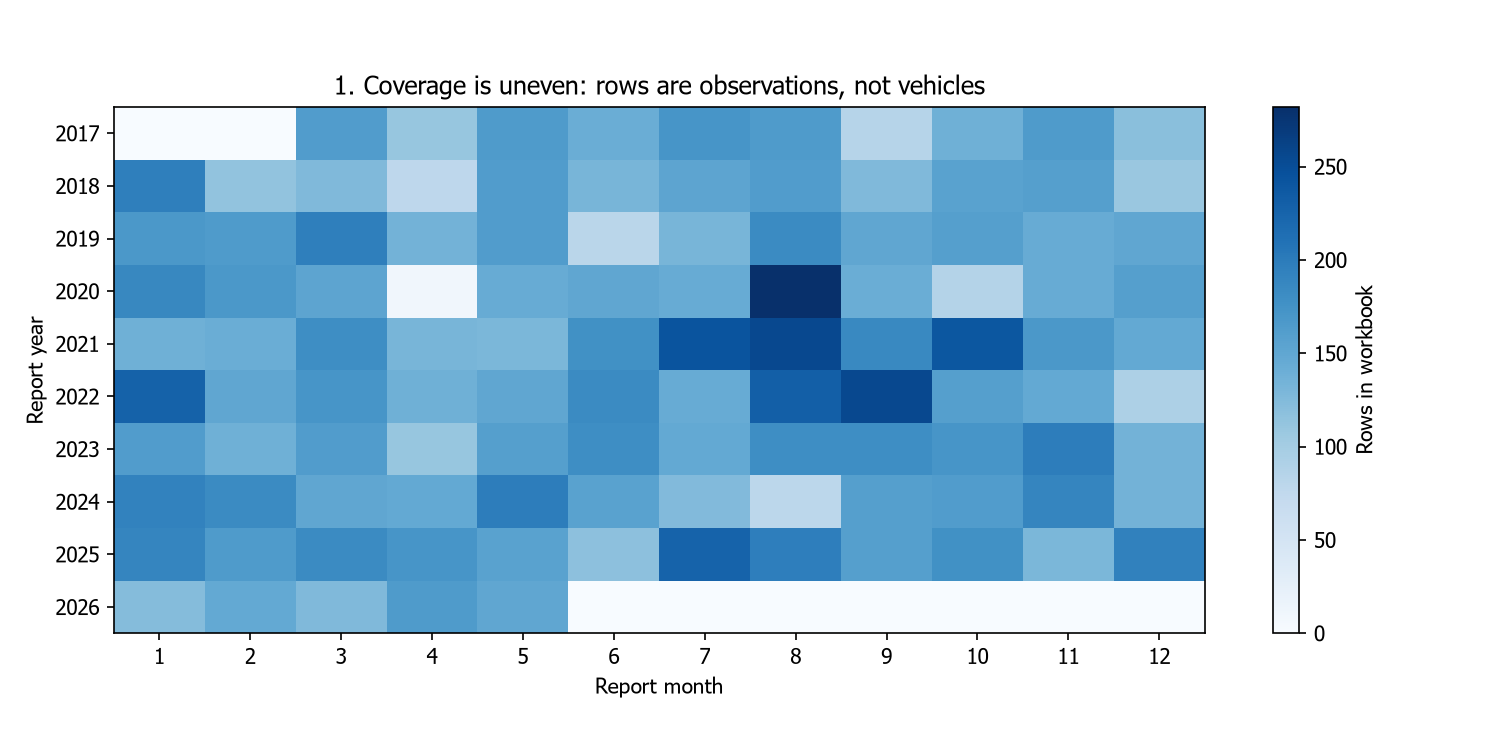

### 2. ภาพรวมของชุดที่จับคู่ได้

During=91.5; After=90.2; Before=100

ไม่ใช่ผลเชิงสาเหตุ; bootstrap ไม่รวม selection bias และความผิดต้นทาง ไม่ได้ทดสอบ After–During โดยตรง

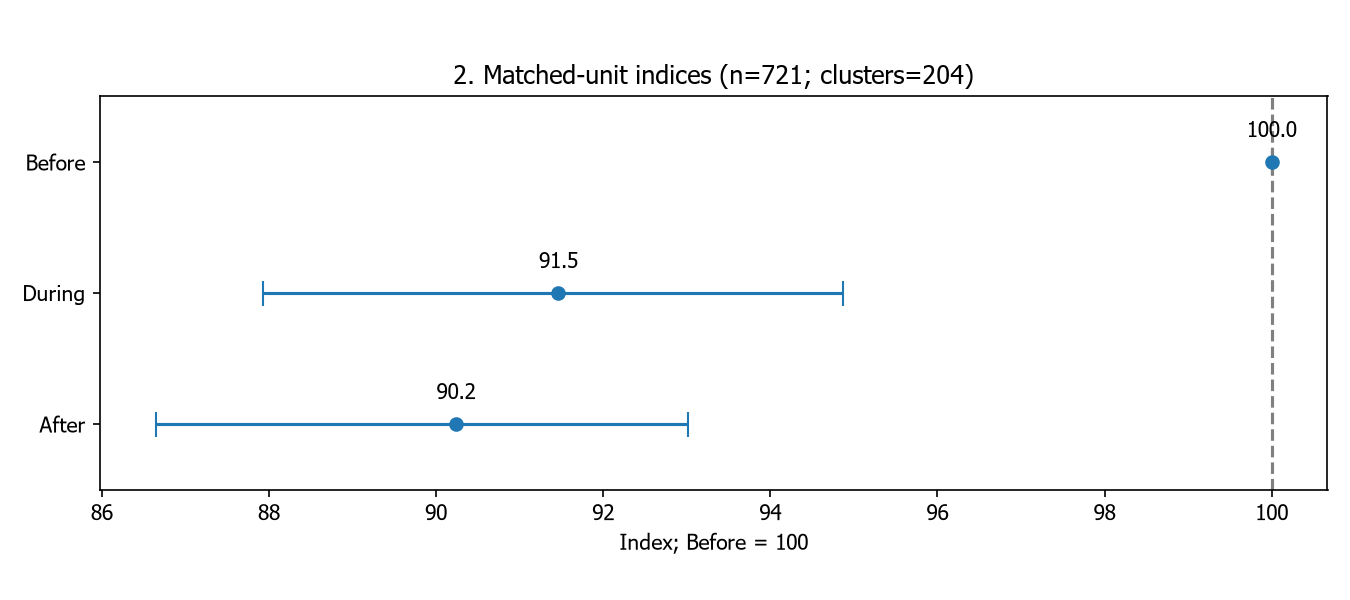

### 3. แต่ละสถานที่เปลี่ยนเหมือนกันหรือไม่

มี 22 คู่เช้าที่สำรวจอย่างน้อยสองรายการทุกช่วง แสดง 12 คู่ที่ผล After ต่างจาก 100 มากที่สุด

ตั้งใจเลือกผลต่างสูง จึงไม่ใช้ภาพนี้เป็นตัวแทนการกระจายทั้งเมือง; ปฏิทินไม่จำเป็นต้องตรงกัน

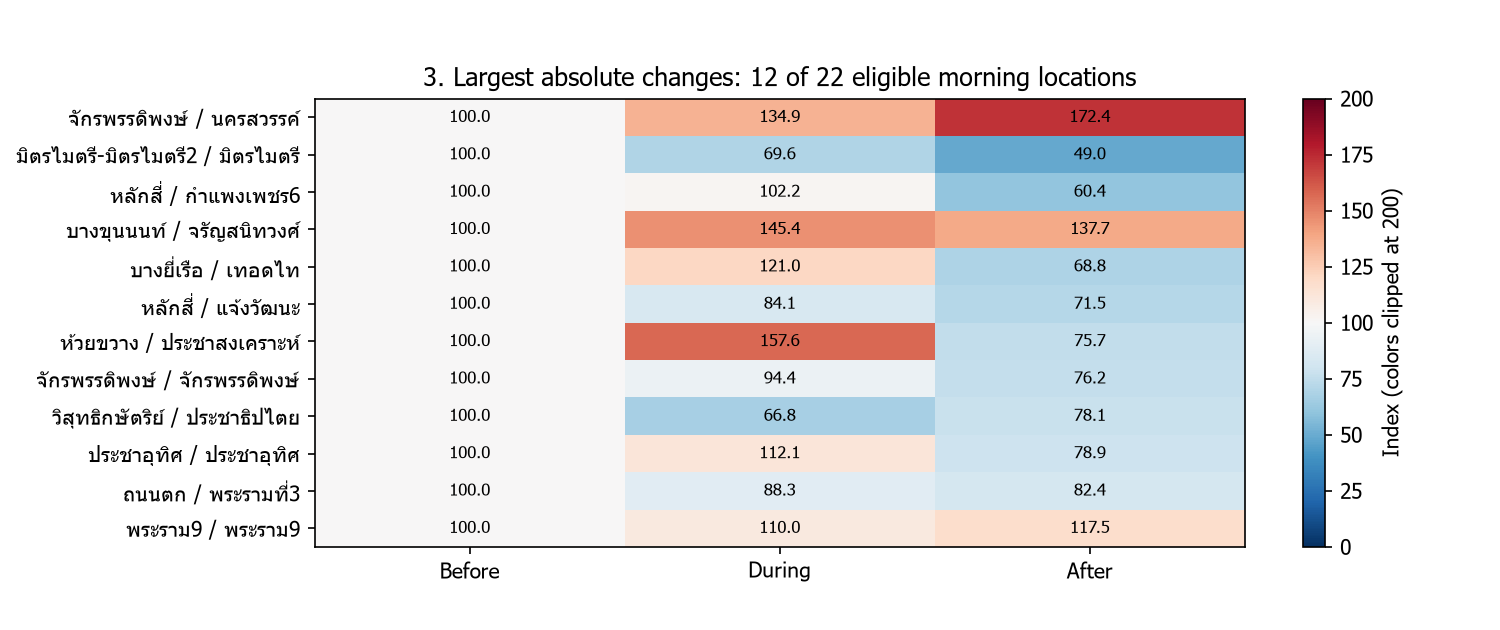

### 4. ประเภทรถในกรณีศึกษาที่ผ่านเกณฑ์ ครบสามช่วง

บางขุนนนท์/จรัญสนิทวงศ์ รถรวมเปลี่ยนมัธยฐาน After เทียบ Before +37.7%; หลักสี่/แจ้งวัฒนะ รถรวมเปลี่ยนมัธยฐาน After เทียบ Before -28.5%

กราฟใช้ค่าเฉลี่ย ส่วนเปอร์เซ็นต์ในข้อความใช้มัธยฐาน; รถยนต์รวมแท็กซี่ ไม่ใช่หลักฐานสาเหตุ

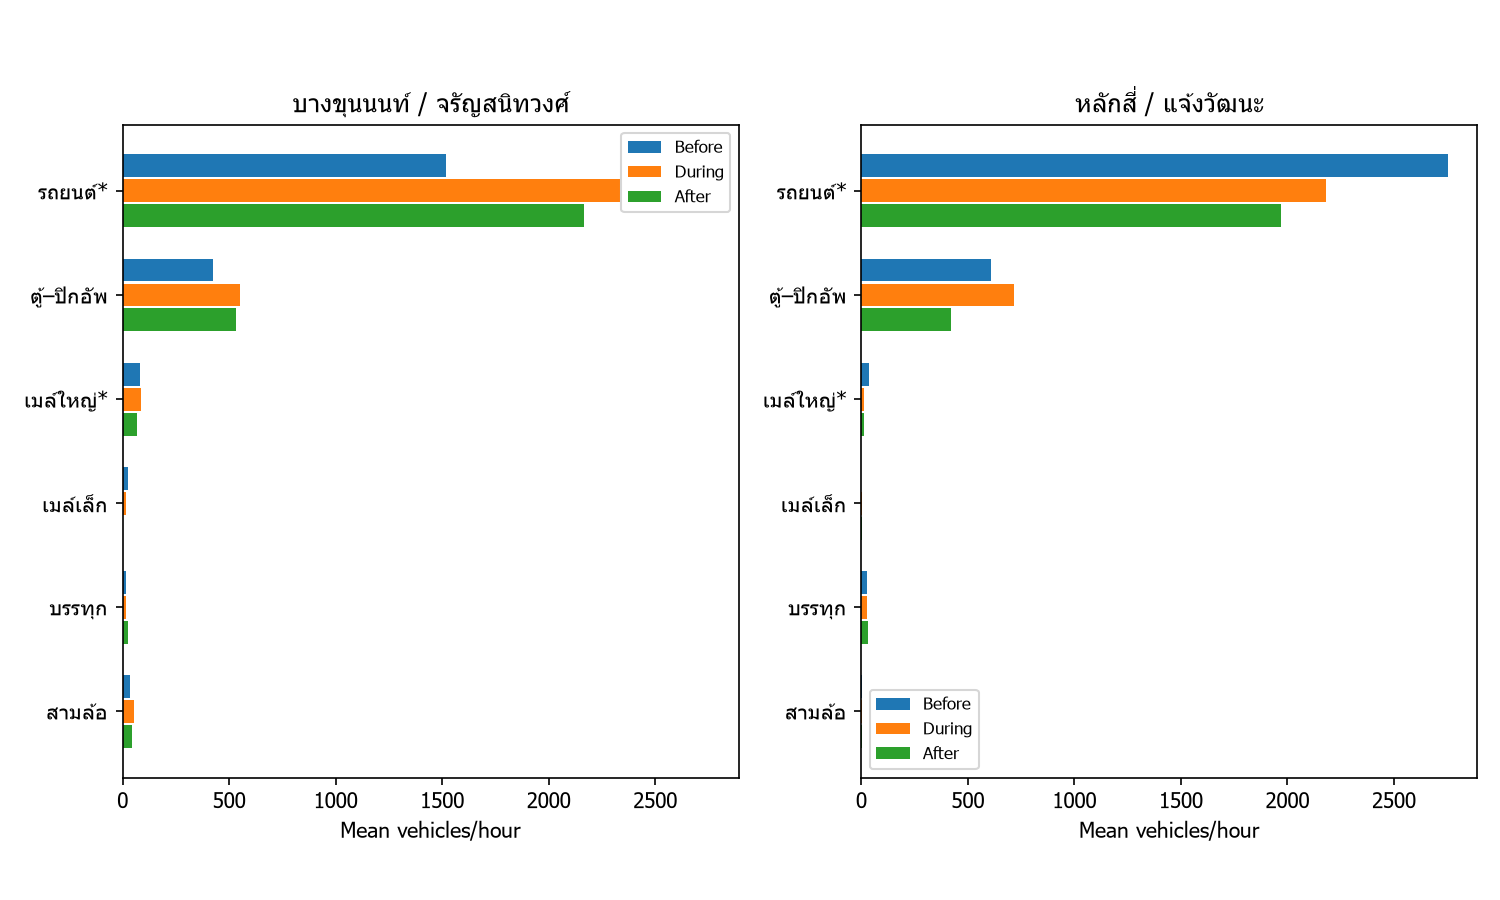

### 5. องค์ประกอบรถ Before–During–After

หมวดรถยนต์ Before=71.72%, During=72.51%, After=73.39% จาก 719 หน่วย

สัดส่วนเพิ่มไม่เท่ากับจำนวนเพิ่ม; หกหมวดไม่ใช่ทุกยานพาหนะและไม่ใช่ผู้โดยสาร

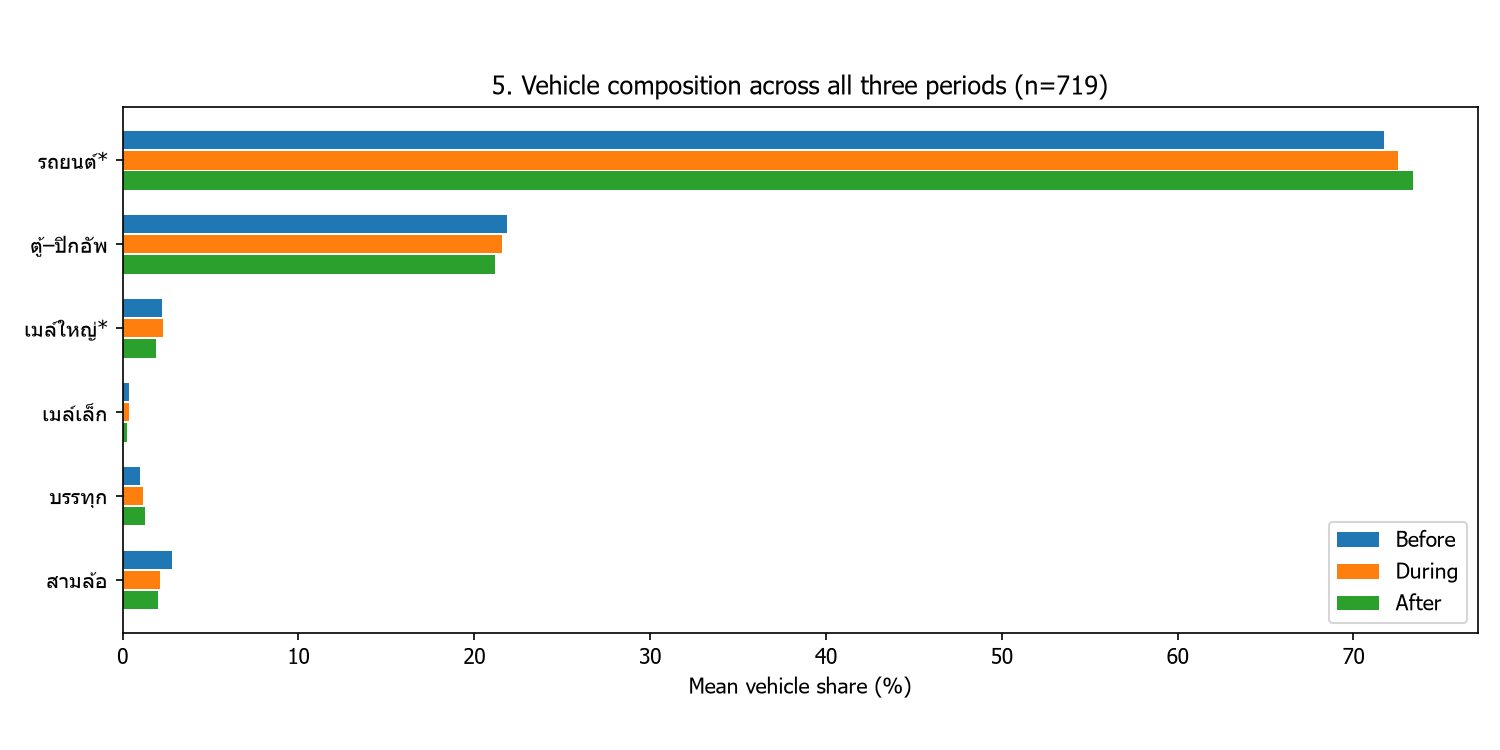

### 6. ข้อสรุปไวต่อเงื่อนไขหรือไม่

Same location/time: n=721, During=91.5, After=90.2; Same report quarter: n=76, During=87.7, After=87.3; Same survey month: n=18, During=87.3, After=94.1

สมาชิกเปลี่ยนเมื่อเพิ่มเงื่อนไข จึงไม่ใช่การทดลองเปลี่ยนเงื่อนไขบนกลุ่มเดิมทั้งหมด

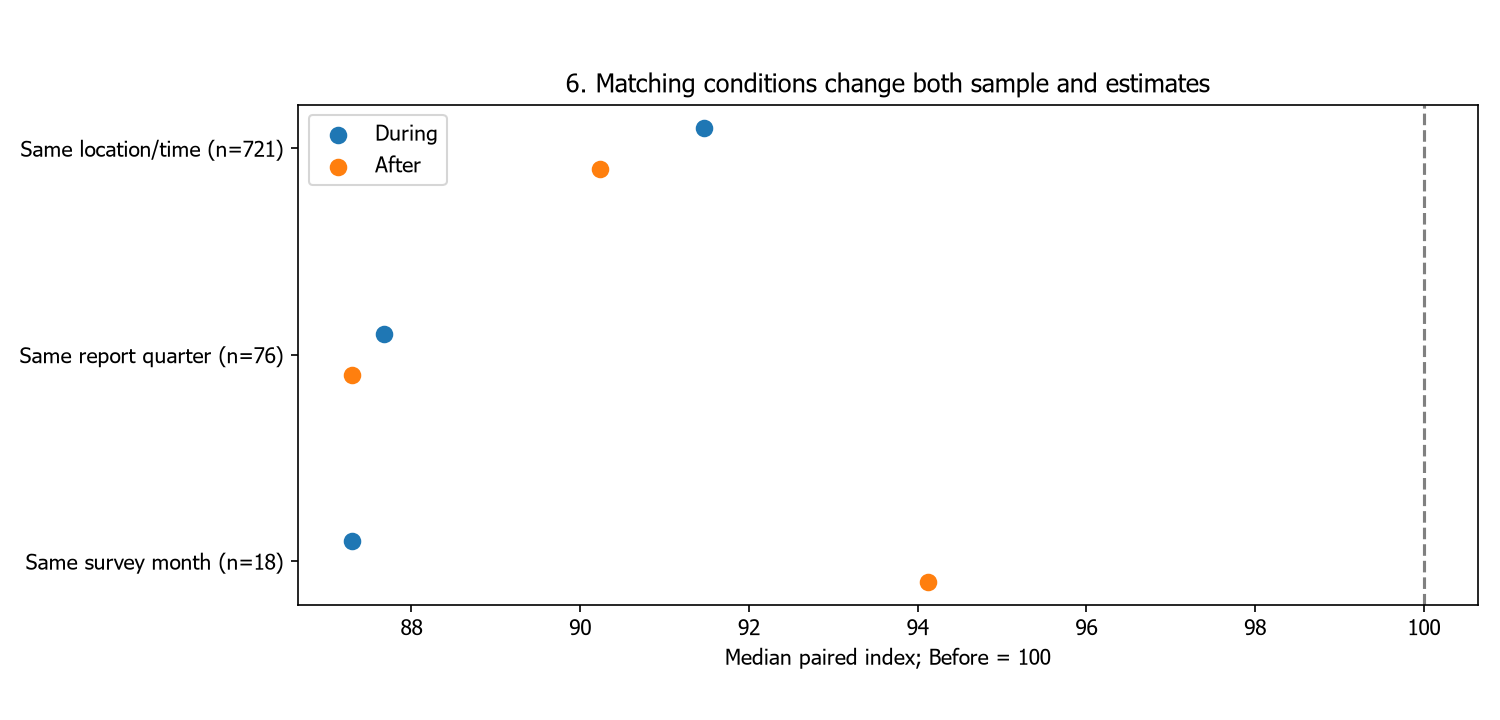

### 7. Lockdown เทียบ Not Lockdown ภายใน During

ตาม flag ผู้ใช้ จับคู่ 129 หน่วย 278 แถว ดัชนี=85.7; Flag ในไฟล์ต่างจากกรอบวันที่อ้างอิง 168 แถว; invalid binary/complement 0 แถว

flag ยังมีแถวต่างจากกรอบวันที่; reference windows เป็นการทดสอบนิยาม ไม่ใช่การแก้ต้นฉบับหรือรับรองทุกช่วงมาตรการ จำนวนคู่ลดมากเมื่อคุมเดือน

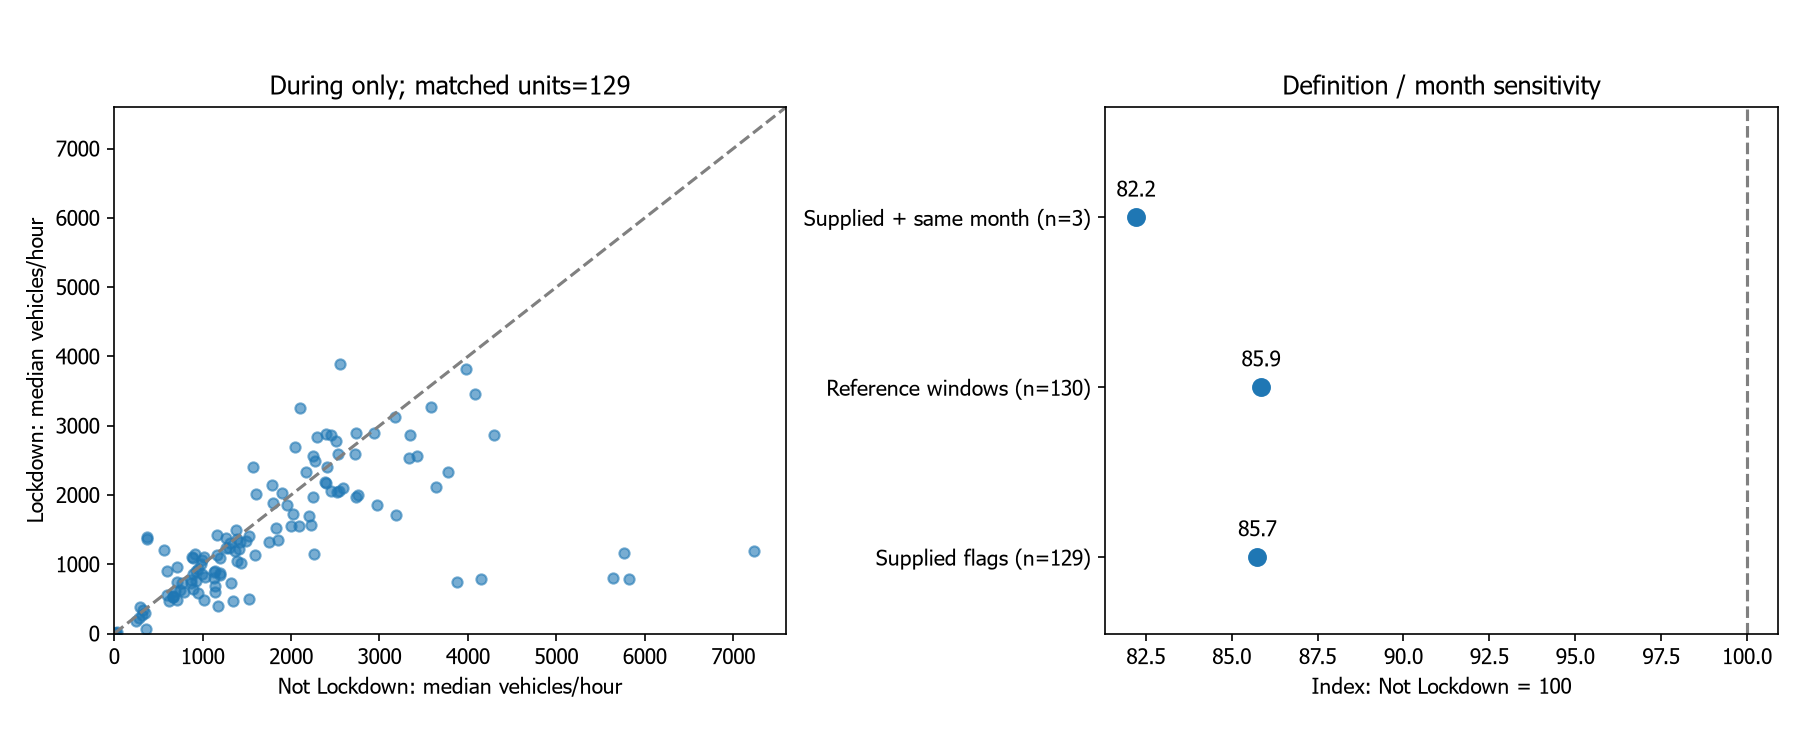

# แนวพูดหน้าชั้นเรียน

เปิดเรื่อง: เราศึกษาปริมาณรถ ณ จุดสำรวจ ไม่ใช่ระดับรถติดทั้งเมือง

## 1. ขอบเขตข้อมูลก่อนตีความ

เริ่มจากตรวจว่าเรามีข้อมูลจุดไหนและเมื่อไร แล้วเปรียบเทียบเฉพาะหน่วยเดียวกัน

ตัวเลขที่พูด: ไฟล์มี 17,440 แถว; ผ่านเกณฑ์ V4 17,250 แถว; จับคู่หลัก 3,045 แถว / 721 หน่วย

ถ้าถูกถาม: ช่องศูนย์หมายถึงไม่มีรายการในไฟล์ ไม่ใช่ไม่มีรถ; ขอบเขตที่ตรวจไม่รับรองว่าเป็นทุกเดือนที่หน่วยงานมี

## 2. ภาพรวมของชุดที่จับคู่ได้

During=91.5; After=90.2; Before=100 เป็นภาพรวมของตัวอย่าง ไม่ใช่รถทั้งหมดในกรุงเทพฯ

ตัวเลขที่พูด: During=91.5; After=90.2; Before=100

ถ้าถูกถาม: ไม่ใช่ผลเชิงสาเหตุ; bootstrap ไม่รวม selection bias และความผิดต้นทาง ไม่ได้ทดสอบ After–During โดยตรง

## 3. แต่ละสถานที่เปลี่ยนเหมือนกันหรือไม่

ดัชนีเปรียบเทียบกับฐานของแต่ละสถานที่ ไม่ใช่อันดับจำนวนรถ

ตัวเลขที่พูด: มี 22 คู่เช้าที่สำรวจอย่างน้อยสองรายการทุกช่วง แสดง 12 คู่ที่ผล After ต่างจาก 100 มากที่สุด

ถ้าถูกถาม: ตั้งใจเลือกผลต่างสูง จึงไม่ใช้ภาพนี้เป็นตัวแทนการกระจายทั้งเมือง; ปฏิทินไม่จำเป็นต้องตรงกัน

## 4. ประเภทรถในกรณีศึกษาที่ผ่านเกณฑ์ ครบสามช่วง

เปรียบเทียบทั้งสามแท่งในหมวดเดียวกันก่อนดูว่าประเภทใดเปลี่ยนสวนทางกัน

ตัวเลขที่พูด: บางขุนนนท์/จรัญสนิทวงศ์ รถรวมเปลี่ยนมัธยฐาน After เทียบ Before +37.7%; หลักสี่/แจ้งวัฒนะ รถรวมเปลี่ยนมัธยฐาน After เทียบ Before -28.5%

ถ้าถูกถาม: กราฟใช้ค่าเฉลี่ย ส่วนเปอร์เซ็นต์ในข้อความใช้มัธยฐาน; รถยนต์รวมแท็กซี่ ไม่ใช่หลักฐานสาเหตุ

## 5. องค์ประกอบรถ Before–During–After

ดูว่าช่วง During และ After ต่างจาก Before อย่างไร ไม่ตีความเป็นการเปลี่ยนไปใช้รถส่วนตัว

ตัวเลขที่พูด: หมวดรถยนต์ Before=71.72%, During=72.51%, After=73.39% จาก 719 หน่วย

ถ้าถูกถาม: สัดส่วนเพิ่มไม่เท่ากับจำนวนเพิ่ม; หกหมวดไม่ใช่ทุกยานพาหนะและไม่ใช่ผู้โดยสาร

## 6. ข้อสรุปไวต่อเงื่อนไขหรือไม่

ไม่เลือกเฉพาะวิธีที่ให้เรื่องราวสวย ต้องรายงานว่าทิศทางเทียบฐานและ After เทียบ During สอดคล้องหรือเปลี่ยนไปอย่างไร

ตัวเลขที่พูด: Same location/time: n=721, During=91.5, After=90.2; Same report quarter: n=76, During=87.7, After=87.3; Same survey month: n=18, During=87.3, After=94.1

ถ้าถูกถาม: สมาชิกเปลี่ยนเมื่อเพิ่มเงื่อนไข จึงไม่ใช่การทดลองเปลี่ยนเงื่อนไขบนกลุ่มเดิมทั้งหมด

## 7. Lockdown เทียบ Not Lockdown ภายใน During

นี่เป็นความสัมพันธ์ในชุดสำรวจปีโควิด ไม่ใช่ผลเชิงสาเหตุของ Lockdown; ไม่รวม Before/After เป็นกลุ่ม Not Lockdown

ตัวเลขที่พูด: ตาม flag ผู้ใช้ จับคู่ 129 หน่วย 278 แถว ดัชนี=85.7; Flag ในไฟล์ต่างจากกรอบวันที่อ้างอิง 168 แถว; invalid binary/complement 0 แถว

ถ้าถูกถาม: flag ยังมีแถวต่างจากกรอบวันที่; reference windows เป็นการทดสอบนิยาม ไม่ใช่การแก้ต้นฉบับหรือรับรองทุกช่วงมาตรการ จำนวนคู่ลดมากเมื่อคุมเดือน

ปิดเรื่อง: ผลช่วยระบุจุดที่ควรตรวจหรือสำรวจซ้ำ ยังไม่แยกสาเหตุของโควิดออกจากปัจจัยอื่น

In [5]:
if (RESULT/'manifest.json').exists():
    import json
    manifest=json.loads((RESULT/'manifest.json').read_text(encoding='utf-8'))
    for chart in manifest['charts']:
        display(Markdown('### '+chart['title']+'\n\n'+chart['finding']+'\n\n'+chart['limit']))
        display(Image(filename=str(RESULT/'figures'/chart['image']),width=1000))
    display(Markdown((RESULT/'Speaker_Notes.md').read_text(encoding='utf-8')))
else:
    print('Audit only. Check STATUS.json and fix input before drawing conclusions.')

## ดาวน์โหลดผลรอบนี้
ZIP รวมภาพ ตาราง README แนวพูด และ HTML สไลด์ ไม่รวมสำเนา Raw Data

In [6]:
from zipfile import ZipFile,ZIP_DEFLATED
ARCHIVE=RESULT.parent/(RESULT.name+'_results.zip')
with ZipFile(ARCHIVE,'w',ZIP_DEFLATED) as z:
    for f in RESULT.rglob('*'):
        if f.is_file() and 'data' not in f.relative_to(RESULT).parts:
            z.write(f,f.relative_to(RESULT))
print(ARCHIVE)
if IN_COLAB:
    print('ดาวน์โหลด ZIP จาก Files ด้านซ้าย')

C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\v4_notebook_test\traffic_v4_runtime\runs\20260919T105753_802328Z_9f3bbdb744_results.zip
